## Collect the info for both cell-types from bcalm and put in to a single table with their metadata
- [ ] get it to run
- [ ] rename nervous to ngn2 and worries to undiff_WTC11 

In [1]:
import ast
import sys
import pandas as pd
import numpy as np # For potential NaN handling if needed
import os


sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
# from importlib import reload
# reload(hf)

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


import yaml

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
# --- Configuration: Define file paths ---
# In a real scenario, these would be command-line arguments or config file entries
input_directory = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/"
NGN2_RESULTS_PATH = config['files']['creating']['NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts']
NGN2_RESULTS_PATH = os.path.join(input_directory, 'NGN2_variant_bcalm_80k_bbmap_selfmadeStrandSensitive_no_outlier_removal_normalized_counts_removed_additional_normalization_2025_05_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv')
undiffWTC11_RESULTS_PATH = os.path.join(input_directory, 'undiffWTC11_variant_bcalm_80k_bbmap_no_outlier_removal_normalized_counts_2025_05_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv')

VARIANT_MAP_PATH = '/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input_tilde2comma.tsv.gz'
METADATA_PATH = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/mpra_metadata_format/MPRA_80215.metadata.tsv.gz'
METADATA_PATH = '/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/notebooks/control_metadata/MPRA_80215.metadata.tsv.gz'

# --- output directory and path ---
# output_directory = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/"
# --- 1. Load Data ---
try:
    NGN2_df = pd.read_csv(NGN2_RESULTS_PATH, sep='\t')
    undiffWTC11_df = pd.read_csv(undiffWTC11_RESULTS_PATH, sep='\t')
    variant_map_df = pd.read_csv(VARIANT_MAP_PATH, sep='\t')
    metadata_df = pd.read_csv(METADATA_PATH, sep='\t')
    # use safe eval on list
    # Apply the safe_eval function to the specified columns
    for col in list_columns:
        metadata_df[col] = metadata_df[col].apply(safe_eval)
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure all TSV files are in the correct directory.")
    exit() # Exit if a critical file is missing

# --- 2. Process variant_map as Base for final_df ---
# This ensures all variants from variant_map are in the final output
final_df = variant_map_df[['ID', 'REF', 'ALT']].copy()
print(f"Initial final_df created from variant_map with {len(final_df)} variants.")

# --- 3. Process Metadata Table ---

# IMPORTANT: Assuming 'category' column in metadata_df can distinguish 'reference' and 'alternative'
# You might need to adjust the filtering logic based on your actual metadata_df content.
# For example, if REF sequences have no 'variant_pos' or col_SPDI, you could use that.
# A common pattern is 'category' or 'class' describing the sequence type.

# Metadata for REF sequences (only 'sequence' needed as 'ref_seq')
metadata_ref = metadata_df[metadata_df['allele'].apply(hf.is_reference)].copy()
if metadata_ref.empty:
    print("Warning: No 'reference' category found in metadata. 'ref_seq' might be missing.")
metadata_ref = metadata_ref[['name', 'sequence', 'chr', 'start', 'end', 'strand']].rename(columns={
    'name': 'REF',
    'sequence': 'ref_seq'
})
print(f"Processed metadata for {len(metadata_ref)} REF sequences.")

# Metadata for ALT sequences ('sequence', 'variant_pos', 'SPDI' needed)
metadata_alt = metadata_df[metadata_df['allele'].apply(hf.is_alternative)].copy()
if metadata_alt.empty:
    print("Warning: No 'alternative' category found in metadata. 'alt_seq', 'variant_pos', 'SPDI' might be missing.")
metadata_alt = metadata_alt[['name', 'sequence', col_variant_pos, col_SPDI]].rename(columns={
    'name': 'ALT',
    'sequence': 'alt_seq'
})
print(f"Processed metadata for {len(metadata_alt)} ALT sequences.")

# --- 4. Merge Metadata onto final_df ---

# Merge ref_seq
final_df = pd.merge(final_df, metadata_ref, on='REF', how='left')
print(f"Merged REF metadata. Columns: {final_df.columns.tolist()}")

# Merge alt_seq, variant_pos, SPDI
final_df = pd.merge(final_df, metadata_alt, on='ALT', how='left')
print(f"Merged ALT metadata. Columns: {final_df.columns.tolist()}")

# --- 5. Process and Merge Result Tables (NGN2 & undiffWTC11) ---

# Process NGN2 results
NGN2_processed = NGN2_df[['variant_id', 'adj.P.Val', 'logFC']].copy()
NGN2_processed.rename(columns={
    'adj.P.Val': 'adjusted_p-value_NGN2',
    'logFC': 'logFC_NGN2'
}, inplace=True)
NGN2_processed['has_readout_NGN2'] = True
print(f"Processed {len(NGN2_processed)} variants for NGN2 cell type.")

# Merge NGN2 results into final_df
final_df = pd.merge(final_df, NGN2_processed, left_on='ID', right_on='variant_id', how='left')
final_df.drop(columns=['variant_id'], inplace=True) # Drop the redundant variant_id column
print(f"Merged NGN2 results. Columns: {final_df.columns.tolist()}")


# Process undiffWTC11 results
undiffWTC11_processed = undiffWTC11_df[['variant_id', 'adj.P.Val', 'logFC']].copy()
undiffWTC11_processed.rename(columns={
    'adj.P.Val': 'adjusted_p-value_undiffWTC11', # Note: keeping original adj.P.Val typo for consistency if it's from the input
    'logFC': 'logFC_undiffWTC11'
}, inplace=True)
undiffWTC11_processed['has_readout_undiffWTC11'] = True
print(f"Processed {len(undiffWTC11_processed)} variants for undiffWTC11 cell type.")

# Merge undiffWTC11 results into final_df
final_df = pd.merge(final_df, undiffWTC11_processed, left_on='ID', right_on='variant_id', how='left')
final_df.drop(columns=['variant_id'], inplace=True) # Drop the redundant variant_id column
print(f"Merged undiffWTC11 results. Columns: {final_df.columns.tolist()}")

# --- 6. Handle Missing Readouts ---

# Fill NaN values for 'has_readout' columns with False
final_df['has_readout_NGN2'] = final_df['has_readout_NGN2'].fillna(0).astype('bool')
final_df['has_readout_undiffWTC11'] = final_df['has_readout_undiffWTC11'].fillna(0).astype('bool')
print("Filled NaN values for 'has_readout' columns with False.")

# NaN values in adjusted_p-value and logFC will remain, indicating no measurement.

# Make start and end int columns
final_df['start'] = final_df['start'].astype('Int64')  # Use Int64 for nullable integer
final_df['end'] = final_df['end'].astype('Int64')      # Use Int64 for nullable integer

# Handle SPDI and variant pos lists
# only get the first element from the SPDI column (list)
final_df[col_SPDI] = final_df[col_SPDI].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)

final_df[col_variant_pos] = final_df[col_variant_pos].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
# set to int
final_df[col_variant_pos] = final_df[col_variant_pos].astype('Int64')  # Use Int64 for nullable integer
# --- 7. Final Column Selection and Ordering ---

# Define the exact order of columns
desired_columns = [
    "ID",
    "REF",
    "ALT",
    "SPDI",
    "chr",
    "start",
    "end",
    "strand",
    "ref_seq",
    "alt_seq",
    "variant_pos",
    "adjusted_p-value_NGN2",
    "logFC_NGN2",
    "has_readout_NGN2",
    "adjusted_p-value_undiffWTC11", # Using "adjusted_p-Val" as per your column names for results
    "logFC_undiffWTC11",
    "has_readout_undiffWTC11"
]

# Select and reorder columns
# Use .reindex to handle cases where a column might be missing, filling with NaN
final_df = final_df.reindex(columns=desired_columns)
print(f"Final column order and selection applied. Final shape: {final_df.shape}")

# # --- Display Final Results ---
# print("\n--- Final Overview Table (First 5 Rows) ---")
# print(final_df.head())

print("\n--- Final Table Info ---")
final_df.info()

print("\n--- Missing Values in Final Table (Count) ---")
print(final_df.isnull().sum())

# filter missing spdi rows out
final_df = final_df[final_df[col_SPDI].notna()].copy()
print(f"\nFiltered final_df to remove rows with missing SPDI. Remaining rows: {len(final_df)}")


# Optional: Save the final table to a new TSV file
# output_path = 'variant_overview_table.tsv'
# final_df.to_csv(output_path, sep='\t', index=False)
# print(f"\nFinal table saved to {output_path}")

All data files loaded successfully.
Initial final_df created from variant_map with 47044 variants.
Processed metadata for 18932 REF sequences.
Processed metadata for 47160 ALT sequences.
Merged REF metadata. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand']
Merged ALT metadata. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand', 'alt_seq', 'variant_pos', 'SPDI']
Processed 39498 variants for NGN2 cell type.
Merged NGN2 results. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand', 'alt_seq', 'variant_pos', 'SPDI', 'adjusted_p-value_NGN2', 'logFC_NGN2', 'has_readout_NGN2']
Processed 27384 variants for undiffWTC11 cell type.
Merged undiffWTC11 results. Columns: ['ID', 'REF', 'ALT', 'ref_seq', 'chr', 'start', 'end', 'strand', 'alt_seq', 'variant_pos', 'SPDI', 'adjusted_p-value_NGN2', 'logFC_NGN2', 'has_readout_NGN2', 'adjusted_p-value_undiffWTC11', 'logFC_undiffWTC11', 'has_readout_undiffWTC11']
Filled NaN values for 'has_re

In [3]:
final_df

,ID,REF,ALT,SPDI,chr,start,end,strand,ref_seq,alt_seq,variant_pos,adjusted_p-value_NGN2,logFC_NGN2,has_readout_NGN2,adjusted_p-value_undiffWTC11,logFC_undiffWTC11,has_readout_undiffWTC11
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2179590:T:C,chr1,2179507,2179777,+,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,83,NaN,NaN,False,NaN,NaN,False
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2191443:G:A,chr1,2191262,2191532,+,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,181,NaN,NaN,False,NaN,NaN,False
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192014:G:T,chr1,2191971,2192241,+,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,43,NaN,NaN,False,NaN,NaN,False
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192365:T:G,chr1,2192249,2192519,+,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,116,0.937457,-0.006802,True,NaN,NaN,False
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2193141:G:A,chr1,2192936,2193206,+,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,205,0.942361,-0.005216,True,0.591262,-0.094581,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,NC_000009.12:22031005:G:A,chr9,22030870,22031140,+,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,136,0.052785,0.025681,True,0.843855,0.030803,True
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,NC_000009.12:22094330:A:G,chr9,22094195,22094465,+,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,136,0.364681,-0.031827,True,NaN,NaN,False
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,NC_000009.12:22103341:T:G,chr9,22103206,22103476,+,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,136,0.630572,0.023413,True,0.902283,-0.036917,True
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,NC_000009.12:22124472:C:T,chr9,22124337,22124607,+,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,136,0.860864,0.008103,True,NaN,NaN,False


In [4]:
final_df['start'].isna().sum()

0

In [5]:
# were there prolems with the merging of the SPDI column?
final_df.loc[final_df['SPDI'].isna()].shape[0] # 28
final_df.loc[final_df['SPDI'].isna()]

,ID,REF,ALT,SPDI,chr,start,end,strand,ref_seq,alt_seq,variant_pos,adjusted_p-value_NGN2,logFC_NGN2,has_readout_NGN2,adjusted_p-value_undiffWTC11,logFC_undiffWTC11,has_readout_undiffWTC11


In [6]:
# check the number of missing values between the two cell types
missing_NGN2 = final_df['adjusted_p-value_NGN2'].isna().sum()
missing_undiffWTC11 = final_df['adjusted_p-value_undiffWTC11'].isna().sum()
print(f"\nMissing values in NGN2: {missing_NGN2}, undiffWTC11: {missing_undiffWTC11}")


Missing values in NGN2: 7518, undiffWTC11: 19632


### Investigate the bcalm significant results between the two cell types

In [7]:
# add a column to indicate which variants are significant in NGN2 and undiffWTC11
sig_level = 0.1
final_df['significant_variant_NGN2'] = final_df['adjusted_p-value_NGN2'] < sig_level
final_df['significant_variant_undiffWTC11'] = final_df['adjusted_p-value_undiffWTC11'] < sig_level
# count the number of significant variants in each cell type
num_sig_NGN2 = final_df['significant_variant_NGN2'].sum()
num_sig_undiffWTC11 = final_df['significant_variant_undiffWTC11'].sum()
print(f"\nSignificance threshold set to: {sig_level}")
print(f"Number of significant variants in NGN2: {final_df['significant_variant_NGN2'].sum()}")
print(f"Number of significant variants in undiffWTC11: {final_df['significant_variant_undiffWTC11'].sum()}")



Significance threshold set to: 0.1
Number of significant variants in NGN2: 1212
Number of significant variants in undiffWTC11: 86


Generate a upset plot of the has_readout and the significant_variant columns


Prepared data for Readout Presence Upset Plot.
Prepared data for Significant Variants Upset Plot.


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will ch

<Figure size 1000x600 with 0 Axes>

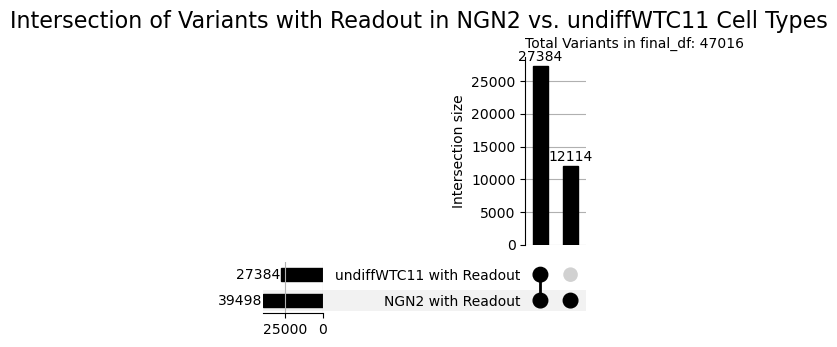

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

<Figure size 1000x600 with 0 Axes>

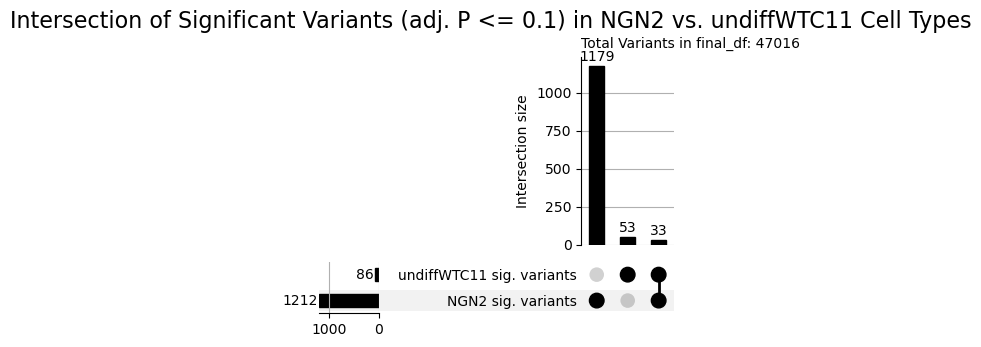


Upset plots generated. Please check your plot window/output.


In [8]:
# --- 2. Prepare Data for Upset Plots ---
from upsetplot import plot, from_contents # Import 'plot' and 'from_contents'
import matplotlib.pyplot as plt
# Plot 1: Readout Presence
# Create a dictionary of sets or a Series with MultiIndex for UpSetPlot
readout_sets = from_contents({
    'NGN2 with Readout': final_df[final_df['has_readout_NGN2']].index,
    'undiffWTC11 with Readout': final_df[final_df['has_readout_undiffWTC11']].index,
})
print("\nPrepared data for Readout Presence Upset Plot.")

# Plot 2: Significant Variants
significant_sets = from_contents({
    'NGN2 sig. variants': final_df[final_df['significant_variant_NGN2']].index,
    'undiffWTC11 sig. variants': final_df[final_df['significant_variant_undiffWTC11']].index,
})
print("Prepared data for Significant Variants Upset Plot.")

# --- 3. Generate Upset Plots ---

# Ensure matplotlib is set up for plotting
plt.figure(figsize=(10, 6)) # Adjust figure size as needed
plot(readout_sets, show_counts=True, sort_by='cardinality', element_size=30, min_subset_size=1)
plt.suptitle('Intersection of Variants with Readout in NGN2 vs. undiffWTC11 Cell Types', y=1.02, fontsize=16)
plt.title(f'Total Variants in final_df: {len(final_df)}', fontsize=10, loc='left')
plt.show()

plt.figure(figsize=(10, 6)) # Adjust figure size as needed
plot(significant_sets, show_counts=True, sort_by='cardinality', element_size=30, min_subset_size=1)
plt.suptitle(f'Intersection of Significant Variants (adj. P <= {sig_level}) in NGN2 vs. undiffWTC11 Cell Types', y=1.02, fontsize=16)
plt.title(f'Total Variants in final_df: {len(final_df)}', fontsize=10, loc='left')
plt.show()

print("\nUpset plots generated. Please check your plot window/output.")

### For variants which are significant in both check their correlation

In [9]:
final_df.significant_variant_NGN2.sum()
final_df.columns

['ID', 'logFC_NGN2', 'logFC_undiffWTC11', 'significant_variant_NGN2','significant_variant_undiffWTC11']

['ID',
 'logFC_NGN2',
 'logFC_undiffWTC11',
 'significant_variant_NGN2',
 'significant_variant_undiffWTC11']


final_df Head with Combined Significance:
   significant_variant_NGN2  significant_variant_undiffWTC11  \
0                     False                            False   
1                     False                            False   
2                     False                            False   
3                     False                            False   
4                     False                            False   

  combined_significance  
0       Not Significant  
1       Not Significant  
2       Not Significant  
3       Not Significant  
4       Not Significant  

Combined Significance Group Counts:
combined_significance
Not Significant                    45751
Significant in NGN2 Only            1179
Significant in undiffWTC11 Only       53
Significant in Both                   33
Name: count, dtype: int64

Generating scatter plot of variant logFC correlation...


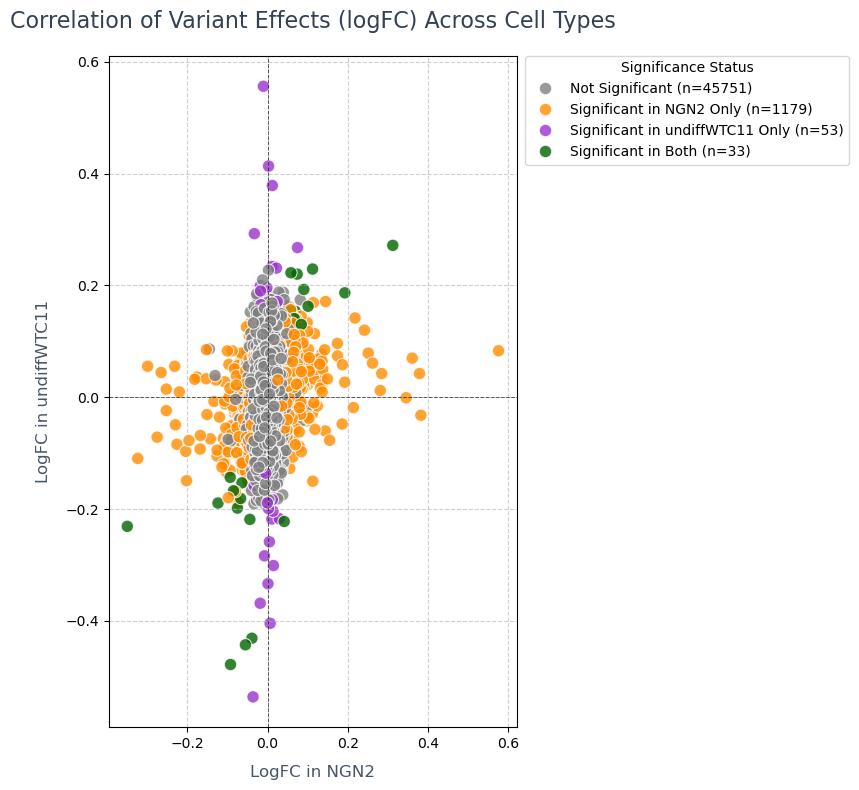

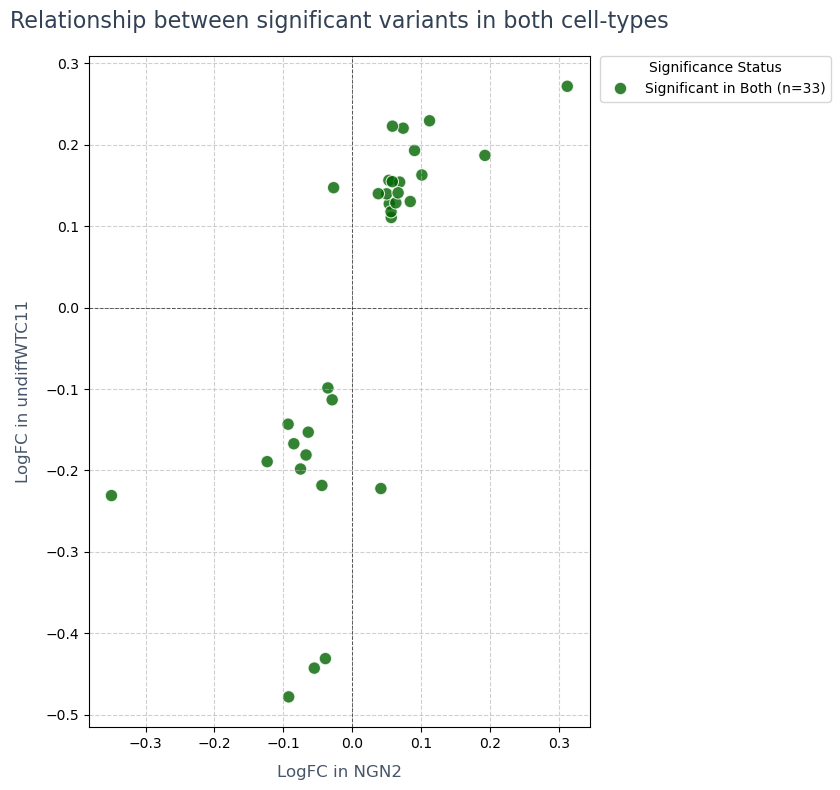

In [10]:
import seaborn as sns

def add_combined_significance_column(df):
    """
    Adds a 'combined_significance' column based on the boolean significance columns.
    """
    def get_combined_significance(row):
        sig_ngn2 = row['significant_variant_NGN2']
        sig_undiff = row['significant_variant_undiffWTC11']

        if sig_ngn2 and sig_undiff:
            return 'Significant in Both'
        elif sig_ngn2 and not sig_undiff:
            return 'Significant in NGN2 Only'
        elif not sig_ngn2 and sig_undiff:
            return 'Significant in undiffWTC11 Only'
        else:
            return 'Not Significant'

    df['combined_significance'] = df.apply(get_combined_significance, axis=1)
    return df

def plot_variant_correlation(df, title='Correlation of Variant Effects (logFC) Across Cell Types'):
    """
    Creates a scatter plot of logFC correlation, colored by combined significance.

    Args:
        df (pd.DataFrame): The input DataFrame with logFC and significance data.
    """
    x_col = 'logFC_NGN2'
    y_col = 'logFC_undiffWTC11'
    color_col = 'combined_significance'

    # Define a distinct color palette for the combined significance groups
    color_palette = {
        'Significant in Both': 'darkgreen',
        'Significant in NGN2 Only': 'darkorange',
        'Significant in undiffWTC11 Only': 'darkorchid',
        'Not Significant': 'gray'
    }

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=color_col,
        palette=color_palette,
        s=80, # Slightly larger markers
        alpha=0.8, # Slightly less transparent
        edgecolor='w',
        linewidth=0.8
    )

    plt.title(title,
              fontsize=16, color='#334155', pad=20)
    plt.xlabel('LogFC in NGN2', fontsize=12, color='#475569', labelpad=10)
    plt.ylabel('LogFC in undiffWTC11', fontsize=12, color='#475569', labelpad=10)

    # Add lines at x=0 and y=0 for reference
    plt.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.6)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.6)

    # Calculate group sizes for the legend
    group_sizes = df[color_col].value_counts().to_dict()

    # Get current legend handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()

    # Update labels with group sizes
    updated_labels = []
    for label in labels:
        if label in group_sizes:
            updated_labels.append(f"{label} (n={group_sizes[label]})")
        else:
            updated_labels.append(label) # Keep legend title as is

    # Re-create the legend with updated labels
    plt.legend(handles, updated_labels, title='Significance Status',
               bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent legend from overlapping
    plt.show()


# add the significants group column
final_df = add_combined_significance_column(final_df)
print("\nfinal_df Head with Combined Significance:")
print(final_df[['significant_variant_NGN2', 'significant_variant_undiffWTC11', 'combined_significance']].head())
print("\nCombined Significance Group Counts:")
print(final_df['combined_significance'].value_counts())

# 3. Create and display the scatter plot
print("\nGenerating scatter plot of variant logFC correlation...")
plot_variant_correlation(final_df, title='Correlation of Variant Effects (logFC) Across Cell Types')

both_sig_final_df = final_df.loc[final_df['significant_variant_NGN2'] & final_df['significant_variant_undiffWTC11']].copy()
plot_variant_correlation(both_sig_final_df, title='Relationship between significant variants in both cell-types')


In [11]:
# final_df.to_csv("/home/kisa/coding/80K_MPRA/collaborations/ludwig_gwas_annotation_data/ngn2_undiffWTC11_combined_variant_info.tsv", sep='\t', index=False)

#### Compare the effect sizes of the two cell types and the effect directions

In [12]:
# Cell type names as variables for easy adjustment
CELL_TYPE_1_NAME = "NGN2"
CELL_TYPE_2_NAME = "undiffWTC11"

In [13]:
# --- Categorize Significant Variants ---
# Initialize with a default category, e.g., 'Not Significant' or NaN
final_df['significance_group'] = np.nan # Use NaN or a string like 'Not Significant'

# Significant in both
both_mask = (final_df[f'significant_variant_{CELL_TYPE_1_NAME}']) & (final_df[f'significant_variant_{CELL_TYPE_2_NAME}'])
final_df.loc[both_mask, 'significance_group'] = 'Significant in Both'

# Significant in NGN2 only
NGN2_only_mask = (final_df[f'significant_variant_{CELL_TYPE_1_NAME}']) & (~final_df[f'significant_variant_{CELL_TYPE_2_NAME}'] | final_df[f'significant_variant_{CELL_TYPE_2_NAME}'].isna())
final_df.loc[NGN2_only_mask, 'significance_group'] = f'Significant in {CELL_TYPE_1_NAME} Only'

# Significant in undiffWTC11 only
undiffWTC11_only_mask = (~final_df[f'significant_variant_{CELL_TYPE_1_NAME}'] | final_df[f'significant_variant_{CELL_TYPE_1_NAME}'].isna()) & (final_df[f'significant_variant_{CELL_TYPE_2_NAME}'])
final_df.loc[undiffWTC11_only_mask, 'significance_group'] = f'Significant in {CELL_TYPE_2_NAME} Only'

print("\nCategorized significant variants into groups:")
print(final_df['significance_group'].value_counts(dropna=False)) # dropna=False to see counts of NaNs (non-significant variants)

# Filter for only significant variants for further plotting
significant_variants_df = final_df[final_df['significance_group'].notna()].copy()
print(f"\nFiltered to {len(significant_variants_df)} variants that are significant in at least one cell type.")



Categorized significant variants into groups:
significance_group
NaN                                45751
Significant in NGN2 Only            1179
Significant in undiffWTC11 Only       53
Significant in Both                   33
Name: count, dtype: int64

Filtered to 1265 variants that are significant in at least one cell type.


/tmp/ipykernel_178713/3360985879.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Significant in Both' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df.loc[both_mask, 'significance_group'] = 'Significant in Both'


In [14]:
significant_variants_df['significance_group'].value_counts()

significance_group
Significant in NGN2 Only           1179
Significant in undiffWTC11 Only      53
Significant in Both                  33
Name: count, dtype: int64

This does not make sense to me because what is the point of comparing the effect size of the set which is only significant in one cell-type and might not even be tested in the other cell-type? 
- we can only compare the variants which are tested and have readouts in both cell-types. 
- First cell-type specific variants like vulcano plots and the effect size and the effect direction 
- And then: the variant with readouts in both cell-types
    - is the effect different within the variants which are significant between the two cell-types? 


Generating CORRECTED Stacked Bar Plot for variants significant in BOTH cell types...


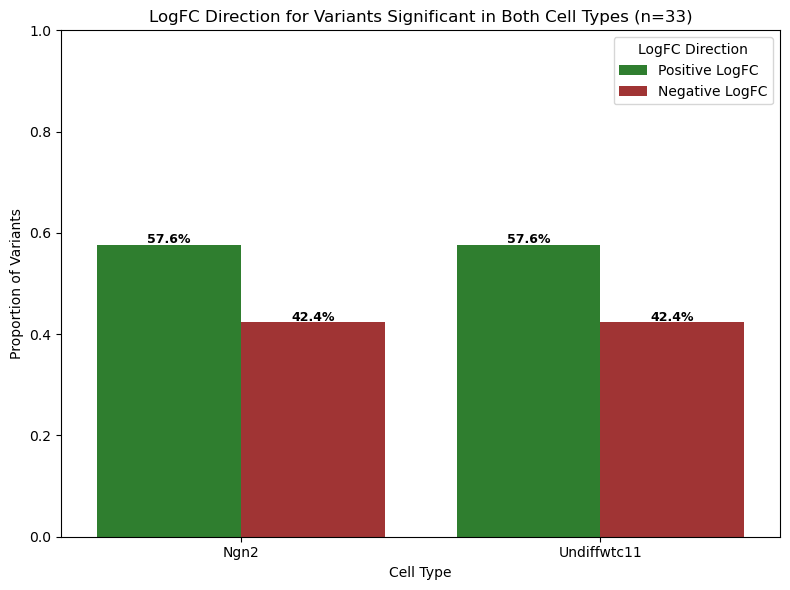

Corrected Stacked Bar Plot for 'Significant in Both' generated.


In [15]:
import seaborn as sns
print("\nGenerating CORRECTED Stacked Bar Plot for variants significant in BOTH cell types...")

both_significant_variants = significant_variants_df[significant_variants_df['significance_group'] == 'Significant in Both'].copy()
bar_plot_data_both = []
total_variants_in_both = len(both_significant_variants)

if total_variants_in_both > 0:
    # --- Data for CELL_TYPE_1_NAME ---
    pos_count_c1 = (both_significant_variants[f'logFC_{CELL_TYPE_1_NAME}'] > 0).sum()
    neg_count_c1 = (both_significant_variants[f'logFC_{CELL_TYPE_1_NAME}'] < 0).sum()
    # If there are any variants with logFC = 0 (which are neither pos nor neg), they won't be counted here.
    # We should normalize by the sum of pos_count_c1 + neg_count_c1, not total_variants_in_both,
    # unless we explicitly want to show 0-logFC variants as a third category.
    # For now, let's assume we're interested in the proportion of *non-zero* logFC.
    # If total_count_c1 is 0, the proportions will be 0.
    total_non_zero_c1 = pos_count_c1 + neg_count_c1

    if total_non_zero_c1 > 0:
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_1_NAME.capitalize(),
            'Direction': 'Positive LogFC',
            'Proportion': pos_count_c1 / total_non_zero_c1
        })
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_1_NAME.capitalize(),
            'Direction': 'Negative LogFC',
            'Proportion': neg_count_c1 / total_non_zero_c1
        })
    else: # Handle case where all logFC are zero or NaN for this cell type in the 'both' group
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_1_NAME.capitalize(),
            'Direction': 'Positive LogFC',
            'Proportion': 0.0
        })
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_1_NAME.capitalize(),
            'Direction': 'Negative LogFC',
            'Proportion': 0.0
        })

    # --- Data for CELL_TYPE_2_NAME ---
    pos_count_c2 = (both_significant_variants[f'logFC_{CELL_TYPE_2_NAME}'] > 0).sum()
    neg_count_c2 = (both_significant_variants[f'logFC_{CELL_TYPE_2_NAME}'] < 0).sum()
    total_non_zero_c2 = pos_count_c2 + neg_count_c2

    if total_non_zero_c2 > 0:
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_2_NAME.capitalize(),
            'Direction': 'Positive LogFC',
            'Proportion': pos_count_c2 / total_non_zero_c2
        })
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_2_NAME.capitalize(),
            'Direction': 'Negative LogFC',
            'Proportion': neg_count_c2 / total_non_zero_c2
        })
    else: # Handle case where all logFC are zero or NaN for this cell type in the 'both' group
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_2_NAME.capitalize(),
            'Direction': 'Positive LogFC',
            'Proportion': 0.0
        })
        bar_plot_data_both.append({
            'Cell Type': CELL_TYPE_2_NAME.capitalize(),
            'Direction': 'Negative LogFC',
            'Proportion': 0.0
        })

    bar_plot_df_both = pd.DataFrame(bar_plot_data_both)

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        data=bar_plot_df_both,
        x='Cell Type',
        y='Proportion',
        hue='Direction',
        palette={'Positive LogFC': 'forestgreen', 'Negative LogFC': 'firebrick'},
        # No dodge=False needed as the dataframe already has the proportions for stacking
        # seaborn's barplot automatically stacks if `y` is numeric and `hue` is present
    )
    plt.title(f'LogFC Direction for Variants Significant in Both Cell Types (n={total_variants_in_both})')
    plt.ylabel('Proportion of Variants')
    plt.xlabel('Cell Type')
    plt.ylim(0, 1)

    plt.legend(title='LogFC Direction')

    for container in ax.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            if height > 0.01: # Only annotate if slice is large enough
                ax.text(x_val + width / 2, y_val + height * 1.02,
                        f'{height:.1%}', ha='center', va='center', color='black', fontsize=9,
                        fontweight='bold')

    plt.tight_layout()
    plt.show()
    print("Corrected Stacked Bar Plot for 'Significant in Both' generated.")
else:
    print("Skipping Stacked Bar Plot: No variants found significant in both cell types.")


In [16]:
both_significant_variants

,ID,REF,ALT,SPDI,chr,start,end,strand,ref_seq,alt_seq,...,adjusted_p-value_NGN2,logFC_NGN2,has_readout_NGN2,adjusted_p-value_undiffWTC11,logFC_undiffWTC11,has_readout_undiffWTC11,significant_variant_NGN2,significant_variant_undiffWTC11,combined_significance,significance_group
2941,cardiac_neuro_cava_random:ALT_CNN3|ENSG0000011...,cardiac_neuro_cava_random:REF_CNN3|ENSG0000011...,cardiac_neuro_cava_random:ALT_CNN3|ENSG0000011...,NC_000001.11:94874068:C:G,chr1,94873984,94874254,-,CCAGGAAACATGAGGATTCAGTTTGTTTTCTCCCAGACAGCCTGGG...,CCAGGAAACATGAGGATTCAGTTTGTTTTCTCCCAGACAGCCTGGG...,...,2.000925e-02,-0.044035,True,7.259999e-03,-0.218368,True,True,True,Significant in Both,Significant in Both
3928,cardiac_neuro_cava_random:ALT_LMNA|ENSG0000016...,cardiac_neuro_cava_random:REF_LMNA|ENSG0000016...,cardiac_neuro_cava_random:ALT_LMNA|ENSG0000016...,NC_000001.11:156178443:A:C,chr1,156178309,156178579,+,CCTCTTCCACCAAGACTAACCAGCACATCTCTCCCCCCATCACTGC...,CCTCTTCCACCAAGACTAACCAGCACATCTCTCCCCCCATCACTGC...,...,4.759078e-06,0.053774,True,1.665845e-02,0.127421,True,True,True,Significant in Both,Significant in Both
5193,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:REF_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,NC_000001.11:231734632:A:G,chr1,231734392,231734662,+,AAGCTTGTGATCCTGAGAAATTTTGTGTTTTCTGTGTTGTCTATAA...,AAGCTTGTGATCCTGAGAAATTTTGTGTTTTCTGTGTTGTCTATAA...,...,5.309221e-67,-0.349480,True,1.206559e-02,-0.230790,True,True,True,Significant in Both,Significant in Both
6560,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,NC_000010.11:67320209:T:C,chr10,67320023,67320293,-,GTTGGCTTTTTCTAATTTCCTCTTTAAAATTTCTTTAACTTTCCAT...,GTTGGCTTTTTCTAATTTCCTCTTTAAAATTTCTTTAACTTTCCAT...,...,4.891708e-14,-0.075016,True,1.034251e-04,-0.198194,True,True,True,Significant in Both,Significant in Both
7445,cardiac_neuro_cava_random:ALT_RBM20|ENSG000002...,cardiac_neuro_cava_random:REF_RBM20|ENSG000002...,cardiac_neuro_cava_random:ALT_RBM20|ENSG000002...,NC_000010.11:110846541:A:G,chr10,110846297,110846567,+,AGGTCTACAAATCCACCTCCTAATAAAACCTTACTGACTTTTTCCA...,AGGTCTACAAATCCACCTCCTAATAAAACCTTACTGACTTTTTCCA...,...,9.333664e-03,0.053201,True,4.089248e-02,0.156256,True,True,True,Significant in Both,Significant in Both
7825,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,cardiac_neuro_cava_random:REF_HRAS|ENSG0000017...,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,NC_000011.10:517934:A:G,chr11,517796,518066,-,CTCTGGTTTTCCTAGGCAGAGGTCCCTGCGGCCTTCCGCAGTGTTT...,CTCTGGTTTTCCTAGGCAGAGGTCCCTGCGGCCTTCCGCAGTGTTT...,...,1.025243e-05,0.112229,True,1.615951e-02,0.229371,True,True,True,Significant in Both,Significant in Both
8791,cardiac_neuro_cava_random:ALT_LRRC4C|ENSG00000...,cardiac_neuro_cava_random:REF_LRRC4C|ENSG00000...,cardiac_neuro_cava_random:ALT_LRRC4C|ENSG00000...,NC_000011.10:41294862:C:A,chr11,41294621,41294891,-,CAGAACTTCTAAGAATTATATTCTGTAAGTCATTGCTGCATTTATG...,CAGAACTTCTAAGAATTATATTCTGTAATTCATTGCTGCATTTATG...,...,6.453471e-07,0.068864,True,2.993052e-03,0.154058,True,True,True,Significant in Both,Significant in Both
9819,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,NC_000011.10:108301619:T:C,chr11,108301526,108301796,+,AAATGTAAAGTTTCCTAATACAAATTTTAAATTTTAGTTTTGAAAT...,AAATGTAAAGTTTCCTAATACAAATTTTAAATTTTAGTTTTGAAAT...,...,5.390514e-10,0.073953,True,1.490255e-02,0.220242,True,True,True,Significant in Both,Significant in Both
12143,cardiac_neuro_cava_random:ALT_MYH6|ENSG0000019...,cardiac_neuro_cava_random:REF_MYH6|ENSG0000019...,cardiac_neuro_cava_random:ALT_MYH6|ENSG0000019...,NC_000014.9:23448795:T:A,chr14,23448757,23449027,-,CTCATGCAAATGAATCAGAAACTAAACGTTGCTTTCCCCCAAGAAT...,CTCATGCAAATGAATCAGAAACTAAACGTTGCTTTCCCCCAAGAAT...,...,1.632389e-02,-0.029109,True,9.240130e-02,-0.113171,True,True,True,Significant in Bo


Generating Enhanced LogFC Scatter Plot for 'Significant in Both' variants...


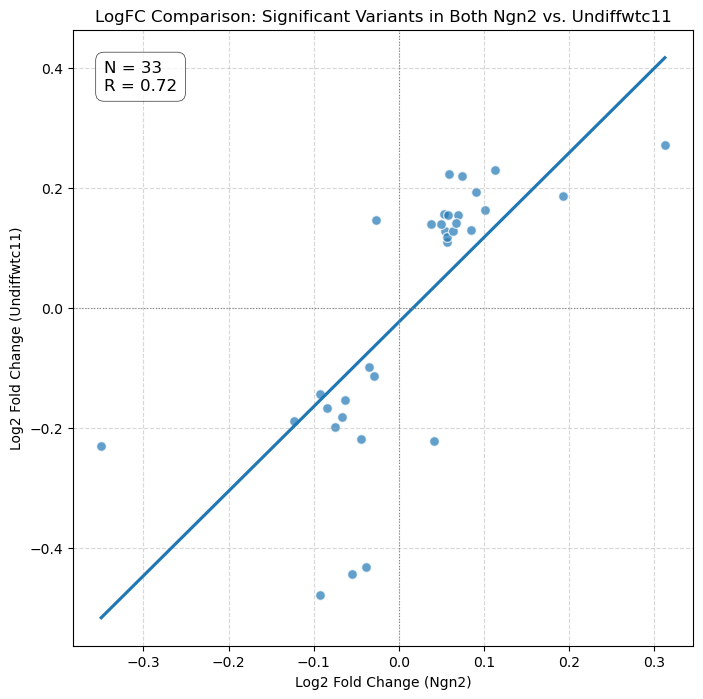

Enhanced LogFC Scatter Plot generated with regression and correlation.


In [17]:
from scipy.stats import pearsonr # For correlation calculation

# --- Enhanced LogFC Scatter Plot for 'Significant in Both' ---
print("\nGenerating Enhanced LogFC Scatter Plot for 'Significant in Both' variants...")

if not both_significant_variants.empty:
    plt.figure(figsize=(8, 8))
    sns.regplot(
        data=both_significant_variants,
        x=f'logFC_{CELL_TYPE_1_NAME}',
        y=f'logFC_{CELL_TYPE_2_NAME}',
        scatter_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'w'},
        ci=None # Do not show confidence interval for the regression
    )
    plt.axvline(0, color='gray', linestyle=':', linewidth=0.8)
    plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)

    # --- CORRECTED PART FOR CORRELATION CALCULATION ---
    # Create a temporary DataFrame with only the relevant logFC columns and drop rows with NaNs
    corr_data = both_significant_variants[[f'logFC_{CELL_TYPE_1_NAME}', f'logFC_{CELL_TYPE_2_NAME}']].dropna()

    corr = np.nan # Initialize correlation as NaN in case corr_data is empty
    n_corr = len(corr_data) # Number of variants used for correlation

    if n_corr > 1: # Pearson correlation requires at least 2 data points
        corr, _ = pearsonr(
            corr_data[f'logFC_{CELL_TYPE_1_NAME}'],
            corr_data[f'logFC_{CELL_TYPE_2_NAME}']
        )
    else:
        print(f"Warning: Not enough non-NaN data points ({n_corr}) to compute correlation for {CELL_TYPE_1_NAME} vs {CELL_TYPE_2_NAME}.")


    plt.title(f'LogFC Comparison: Significant Variants in Both {CELL_TYPE_1_NAME.capitalize()} vs. {CELL_TYPE_2_NAME.capitalize()}')
    plt.xlabel(f'Log2 Fold Change ({CELL_TYPE_1_NAME.capitalize()})')
    plt.ylabel(f'Log2 Fold Change ({CELL_TYPE_2_NAME.capitalize()})')

    # Add correlation and variant count to the plot
    # Display 'N = 0' if no valid points, and 'R = NaN' if correlation couldn't be computed
    plt.text(0.05, 0.95, f'N = {n_corr}\nR = {corr:.2f}' if not np.isnan(corr) else f'N = {n_corr}\nR = N/A',
             transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=0.5, alpha=0.8))

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print("Enhanced LogFC Scatter Plot generated with regression and correlation.")
else:
    print("Skipping Enhanced LogFC Scatter Plot: No variants found significant in both cell types.")

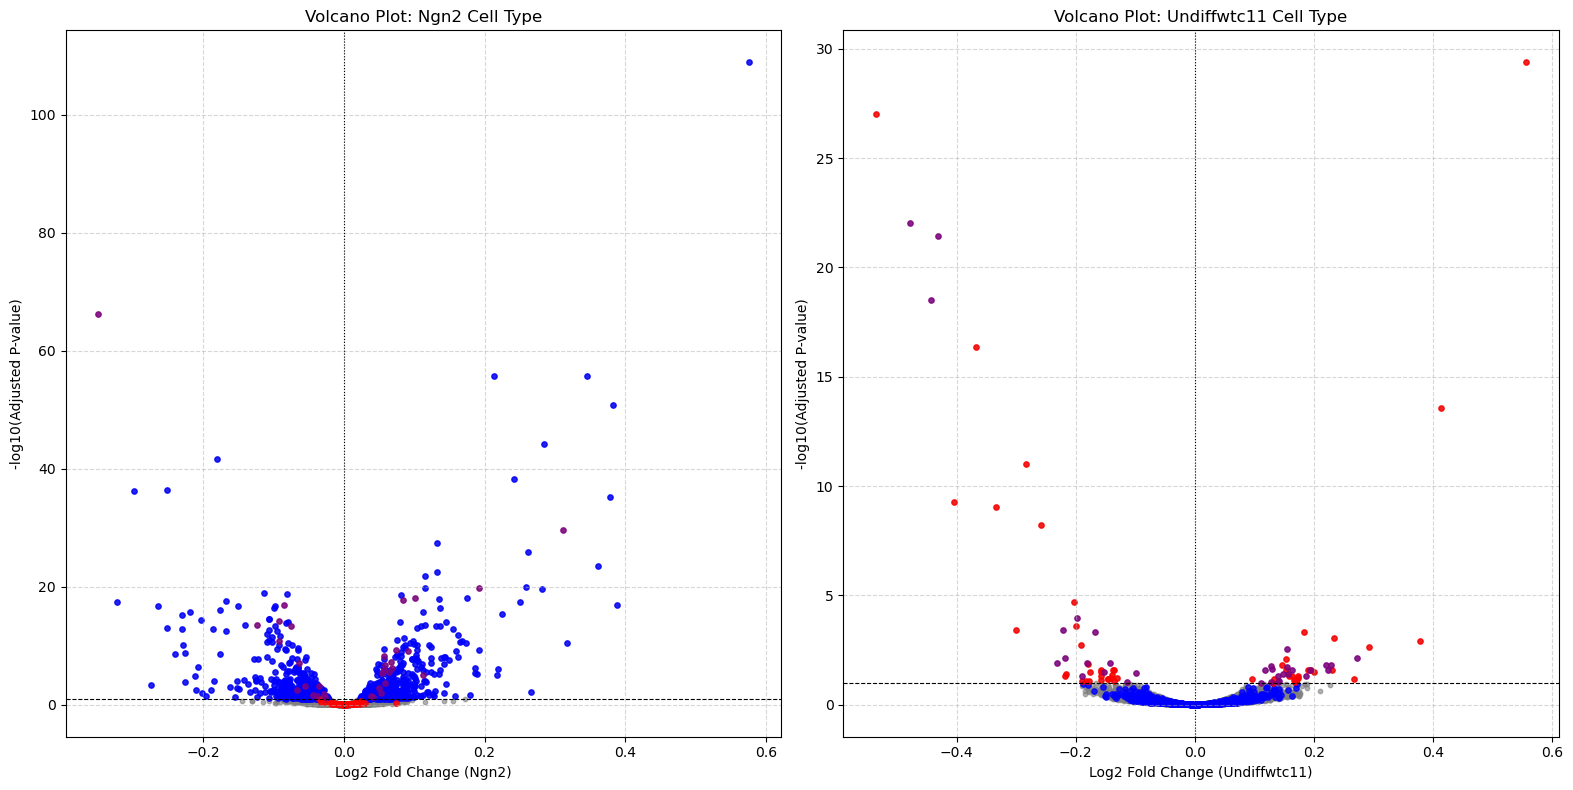


Side-by-Side Volcano Plots generated with external legends.


In [18]:
# --- Visualization: Side-by-Side Volcano Plots (Legend outside) ---

plot_nervous_df = final_df.dropna(subset=[f'adjusted_p-value_{CELL_TYPE_1_NAME}', f'logFC_{CELL_TYPE_1_NAME}']).copy()
plot_worries_df = final_df.dropna(subset=[f'adjusted_p-value_{CELL_TYPE_2_NAME}', f'logFC_{CELL_TYPE_2_NAME}']).copy()

plot_nervous_df['neg_log10_p'] = -np.log10(plot_nervous_df[f'adjusted_p-value_{CELL_TYPE_1_NAME}'])
plot_worries_df['neg_log10_p'] = -np.log10(plot_worries_df[f'adjusted_p-value_{CELL_TYPE_2_NAME}'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

color_map = {
    f'Significant in {CELL_TYPE_1_NAME} Only': 'blue',
    f'Significant in {CELL_TYPE_2_NAME} Only': 'red',
    'Significant in Both': 'purple',
    'Not Significant': 'gray'
}

# --- Volcano Plot for Nervous Cell Type ---
ax1 = axes[0]
ax1.scatter(plot_nervous_df[f'logFC_{CELL_TYPE_1_NAME}'], plot_nervous_df['neg_log10_p'],
            alpha=0.6, s=10, color='gray', label='Not Significant')

for group_name, color in color_map.items():
    if group_name == 'Not Significant': continue
    subset_group = plot_nervous_df[plot_nervous_df['significance_group'] == group_name]
    ax1.scatter(subset_group[f'logFC_{CELL_TYPE_1_NAME}'], subset_group['neg_log10_p'],
                alpha=0.8, s=15, color=color, label=group_name)

ax1.axhline(-np.log10(sig_level), color='black', linestyle='--', linewidth=0.8, label=f'Adj. P = {sig_level}')
ax1.axvline(0, color='black', linestyle=':', linewidth=0.8)

ax1.set_title(f'Volcano Plot: {CELL_TYPE_1_NAME.capitalize()} Cell Type')
ax1.set_xlabel(f'Log2 Fold Change ({CELL_TYPE_1_NAME.capitalize()})')
ax1.set_ylabel('-log10(Adjusted P-value)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(title='Significance Group', loc='center left', bbox_to_anchor=(1, 0.5))
ax1.get_legend().remove()

# --- Volcano Plot for Worries Cell Type ---
ax2 = axes[1]
ax2.scatter(plot_worries_df[f'logFC_{CELL_TYPE_2_NAME}'], plot_worries_df['neg_log10_p'],
            alpha=0.6, s=10, color='gray', label='Not Significant')

for group_name, color in color_map.items():
    if group_name == 'Not Significant': continue
    subset_group = plot_worries_df[plot_worries_df['significance_group'] == group_name]
    ax2.scatter(subset_group[f'logFC_{CELL_TYPE_2_NAME}'], subset_group['neg_log10_p'],
                alpha=0.8, s=15, color=color, label=group_name)

ax2.axhline(-np.log10(sig_level), color='black', linestyle='--', linewidth=0.8, label=f'Adj. P = {sig_level}')
ax2.axvline(0, color='black', linestyle=':', linewidth=0.8)

ax2.set_title(f'Volcano Plot: {CELL_TYPE_2_NAME.capitalize()} Cell Type')
ax2.set_xlabel(f'Log2 Fold Change ({CELL_TYPE_2_NAME.capitalize()})')
ax2.set_ylabel('-log10(Adjusted P-value)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title='Significance Group', loc='center left', bbox_to_anchor=(1, 0.5))
ax2.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()
print("\nSide-by-Side Volcano Plots generated with external legends.")

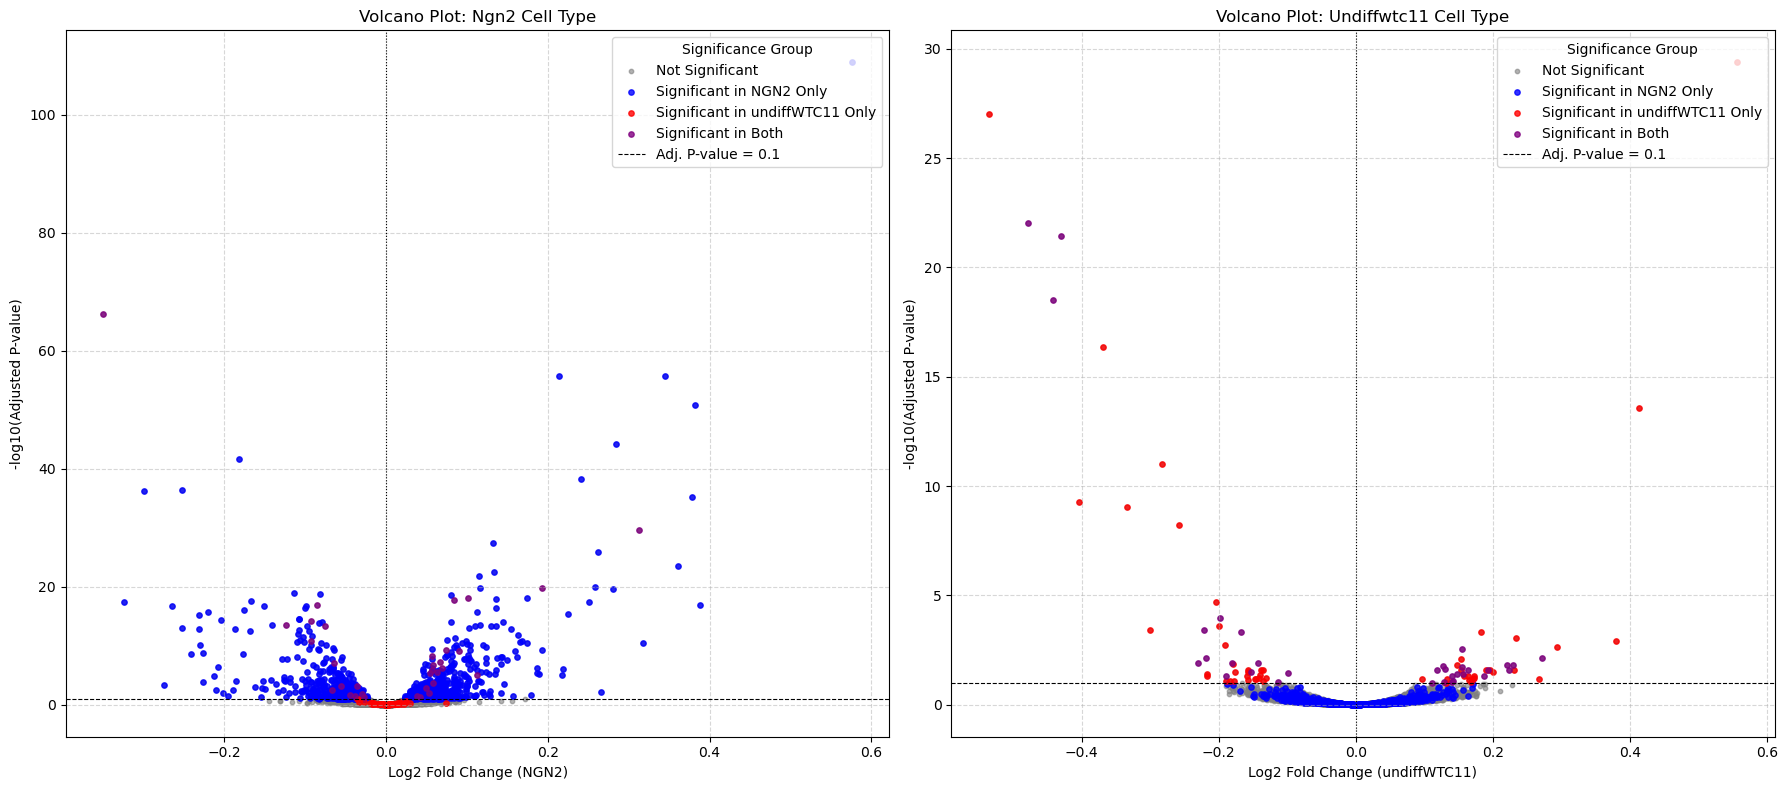


Side-by-Side Volcano Plots generated.


In [19]:
# --- Visualization: Side-by-Side Volcano Plots ---

# Filter out rows where p-value or logFC is NaN, as they can't be plotted
plot_NGN2_df = final_df.dropna(subset=[f'adjusted_p-value_{CELL_TYPE_1_NAME}', f'logFC_{CELL_TYPE_1_NAME}']).copy()
plot_undiffWTC11_df = final_df.dropna(subset=[f'adjusted_p-value_{CELL_TYPE_2_NAME}', f'logFC_{CELL_TYPE_2_NAME}']).copy()

# Calculate -log10(p-value)
plot_NGN2_df['neg_log10_p'] = -np.log10(plot_NGN2_df[f'adjusted_p-value_{CELL_TYPE_1_NAME}'])
plot_undiffWTC11_df['neg_log10_p'] = -np.log10(plot_undiffWTC11_df[f'adjusted_p-value_{CELL_TYPE_2_NAME}'])

# Set up the figure for two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # 1 row, 2 columns

# Define colors for different groups (adjust as desired)
color_map = {
    f'Significant in {CELL_TYPE_1_NAME} Only': 'blue',
    f'Significant in {CELL_TYPE_2_NAME} Only': 'red',
    'Significant in Both': 'purple',
    'Not Significant': 'gray' # For non-significant points
}

# --- Volcano Plot for NGN2 Cell Type ---
ax1 = axes[0]
# First, plot all relevant points in gray
ax1.scatter(plot_NGN2_df[f'logFC_{CELL_TYPE_1_NAME}'], plot_NGN2_df['neg_log10_p'],
            alpha=0.6, s=10, color='gray', label='Not Significant')

# Now, highlight significant points based on their category
# Iterate through the groups to overlay points
for group_name, color in color_map.items():
    if group_name == 'Not Significant': continue # Already plotted

    subset_group = plot_NGN2_df[plot_NGN2_df['significance_group'] == group_name]
    ax1.scatter(subset_group[f'logFC_{CELL_TYPE_1_NAME}'], subset_group['neg_log10_p'],
                alpha=0.8, s=15, color=color, label=group_name)

# Add significance lines
ax1.axhline(-np.log10(sig_level), color='black', linestyle='--', linewidth=0.8, label=f'Adj. P-value = {sig_level}')
ax1.axvline(0, color='black', linestyle=':', linewidth=0.8) # Line at logFC = 0

ax1.set_title(f'Volcano Plot: {CELL_TYPE_1_NAME.capitalize()} Cell Type')
ax1.set_xlabel(f'Log2 Fold Change ({CELL_TYPE_1_NAME})')
ax1.set_ylabel('-log10(Adjusted P-value)')
ax1.legend(title='Significance Group', loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Volcano Plot for undiffWTC11 Cell Type ---
ax2 = axes[1]
# First, plot all relevant points in gray
ax2.scatter(plot_undiffWTC11_df[f'logFC_{CELL_TYPE_2_NAME}'], plot_undiffWTC11_df['neg_log10_p'],
            alpha=0.6, s=10, color='gray', label='Not Significant')

# Now, highlight significant points based on their category
for group_name, color in color_map.items():
    if group_name == 'Not Significant': continue # Already plotted

    subset_group = plot_undiffWTC11_df[plot_undiffWTC11_df['significance_group'] == group_name]
    ax2.scatter(subset_group[f'logFC_{CELL_TYPE_2_NAME}'], subset_group['neg_log10_p'],
                alpha=0.8, s=15, color=color, label=group_name)

# Add significance lines
ax2.axhline(-np.log10(sig_level), color='black', linestyle='--', linewidth=0.8, label=f'Adj. P-value = {sig_level}')
ax2.axvline(0, color='black', linestyle=':', linewidth=0.8) # Line at logFC = 0

ax2.set_title(f'Volcano Plot: {CELL_TYPE_2_NAME.capitalize()} Cell Type')
ax2.set_xlabel(f'Log2 Fold Change ({CELL_TYPE_2_NAME})')
ax2.set_ylabel('-log10(Adjusted P-value)')
ax2.legend(title='Significance Group', loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("\nSide-by-Side Volcano Plots generated.")



In [20]:
# # Write table to file:
# output_directory = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_combined_metadata_table_250616.tsv.gz"
# final_df.to_csv(output_directory, sep='\t', index=False, compression='gzip', na_rep='NA')

#### Write the output to a file for each cell-type
- for the integrated analysis working group or iawg 

In [21]:
final_df.columns

Index(['ID', 'REF', 'ALT', 'SPDI', 'chr', 'start', 'end', 'strand', 'ref_seq',
       'alt_seq', 'variant_pos', 'adjusted_p-value_NGN2', 'logFC_NGN2',
       'has_readout_NGN2', 'adjusted_p-value_undiffWTC11', 'logFC_undiffWTC11',
       'has_readout_undiffWTC11', 'significant_variant_NGN2',
       'significant_variant_undiffWTC11', 'combined_significance',
       'significance_group'],
      dtype='object')

In [22]:
iawg_output_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/IntegrativeAnalysisWorkingGroup"

In [23]:
# --- New Allele Derivation and Sanity Check Function ---

def derive_alleles_and_check_difference(row):
    """
    Derives A1 (reference allele) and A2 (alternative allele)
    by comparing ref_seq and alt_seq at variant_pos.
    Performs a sanity check to ensure ref_seq and alt_seq differ exactly
    at variant_pos and are identical before it.
    Assumes variant_pos is 0-based.
    """
    a1_allele = np.nan
    a2_allele = np.nan
    check_status = True
    check_message = "All sequence difference checks passed"

    # Check for NaN values in critical columns
    required_cols = ['variant_pos', 'ref_seq', 'alt_seq']
    if row[required_cols].isnull().any():
        return np.nan, np.nan, False, f"Missing critical data ({row[required_cols].isnull().sum()} NaNs) for allele derivation in columns: {required_cols}"

    variant_pos_0based = int(row['variant_pos'])
    ref_sequence = str(row['ref_seq'])
    alt_sequence = str(row['alt_seq'])

    len_ref = len(ref_sequence)
    len_alt = len(alt_sequence)

    try:
        # 1. Sanity Check: Sequences must be identical BEFORE variant_pos
        if variant_pos_0based > 0:
            if variant_pos_0based > len_ref or variant_pos_0based > len_alt:
                return np.nan, np.nan, False, f"variant_pos {variant_pos_0based} is beyond one of the sequence lengths ({len_ref}, {len_alt})"
            if ref_sequence[:variant_pos_0based] != alt_sequence[:variant_pos_0based]:
                check_status = False
                check_message = "Sequences differ BEFORE variant_pos"
                # Continue to derive best possible alleles even if this check fails

        # 2. Derive A1 and A2 by finding the first differing base and subsequent matching base
        # This handles SNPs, insertions, and deletions relative to the reference.
        # Find the end of the differing segment
        diff_end_ref = variant_pos_0based
        diff_end_alt = variant_pos_0based

        # Iterate to find the end of the differing segment
        while diff_end_ref < len_ref and diff_end_alt < len_alt:
            if ref_sequence[diff_end_ref] == alt_sequence[diff_end_alt]:
                break # Found the common base after the variant
            diff_end_ref += 1
            diff_end_alt += 1

        # Now, handle indels where one sequence is longer than the other at the end
        # Example: ref: ATC, alt: ATGC. variant_pos=2. diff_end_ref=2, diff_end_alt=3
        # After loop: diff_end_ref will be 2, diff_end_alt will be 3.
        # Check if one sequence ended before the other and they are identical afterwards
        if diff_end_ref < len_ref and diff_end_alt < len_alt:
             if ref_sequence[diff_end_ref:] != alt_sequence[diff_end_alt:]:
                 check_status = False
                 check_message = "Sequences differ AFTER common segment end"

        # Correctly derive A1 and A2 based on the identified differing segments
        a1_allele = ref_sequence[variant_pos_0based:diff_end_ref]
        a2_allele = alt_sequence[variant_pos_0based:diff_end_alt]

        # If A1 and A2 are identical, it's not a variant
        if a1_allele == a2_allele:
             check_status = False
             check_message = "Derived A1 and A2 are identical (not a variant at this position)"

        # Special case: if one allele is empty, means pure insertion/deletion relative to an empty string.
        # This can happen if the sequences are "A" vs "AG" at pos 1. ref_seq[1:] = ""
        # SPDI typically uses a single base context for indels. E.g., A > AT at pos X means ref is A, alt is AT
        # If A1 or A2 is empty, it indicates an indel. We take context base
        if not a1_allele: # Pure insertion like A > AC
            raise ValueError("A1 allele is empty, indicating a pure insertion relative to the reference sequence.")
            a1_allele = ref_sequence[variant_pos_0based-1:variant_pos_0based]
            a2_allele = alt_sequence[variant_pos_0based-1:diff_end_alt]
            check_message += " (Adjusted for pure insertion)" if check_status else ""
        elif not a2_allele: # Pure deletion like AC > A
            raise ValueError("A2 allele is empty, indicating a pure deletion relative to the reference sequence.")
            a1_allele = ref_sequence[variant_pos_0based-1:diff_end_ref]
            a2_allele = alt_sequence[variant_pos_0based-1:variant_pos_0based]
            check_message += " (Adjusted for pure deletion)" if check_status else ""

        # Final check if A1 or A2 are still empty or NaN after adjustments
        if pd.isna(a1_allele) or pd.isna(a2_allele) or not a1_allele or not a2_allele:
            check_status = False
            check_message = "Could not derive valid A1/A2 alleles"

    except IndexError:
        check_status = False
        check_message = f"IndexError: variant_pos {variant_pos_0based} or sequence lengths {len_ref}/{len_alt} caused out-of-bounds access."
    except Exception as e:
        check_status = False
        check_message = f"An unexpected error occurred during allele derivation: {e}"

    return a1_allele, a2_allele, check_status, check_message


# Apply the new derivation and check function
print("\nDeriving A1/A2 alleles and running sequence difference sanity checks...")
final_df[['A1_derived', 'A2_derived', 'seq_check_status', 'seq_check_message']] = final_df.apply(
    lambda row: derive_alleles_and_check_difference(row), axis=1, result_type='expand'
)

# --- Create Variant Tables for Each Cell Type with derived A1/A2 ---

# NGN2 Variant Table
ngn2_readout_df = final_df[final_df[f'has_readout_{CELL_TYPE_1_NAME}']].copy()
ngn2_readout_df['pos'] = ngn2_readout_df["SPDI"].apply(lambda x: int(x.split(':')[1]))
ngn2_table = pd.DataFrame({
    'hg38.chr': ngn2_readout_df['chr'],
    'hg38.pos': ngn2_readout_df['pos'] + 1,  # Convert to 1-based position
    'SPDI': ngn2_readout_df['SPDI'],
    'A1': ngn2_readout_df['A1_derived'], # Use derived allele
    'A2': ngn2_readout_df['A2_derived'],  # Use derived allele
    'AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC': ngn2_readout_df[f'logFC_{CELL_TYPE_1_NAME}'],
    'AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue': ngn2_readout_df[f'adjusted_p-value_{CELL_TYPE_1_NAME}'],
    'AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name': ngn2_readout_df['ALT']
})

print(f"\n{CELL_TYPE_1_NAME.capitalize()} Variant Table (first 5 rows):")
print(ngn2_table.head())
print(f"Total variants with readout in {CELL_TYPE_1_NAME}: {len(ngn2_table)}")


# undiffWTC11 Variant Table
undiffwtc11_readout_df = final_df[final_df[f'has_readout_{CELL_TYPE_2_NAME}']].copy()
undiffwtc11_readout_df['pos'] = undiffwtc11_readout_df["SPDI"].apply(lambda x: int(x.split(':')[1]))
undiffwtc11_table = pd.DataFrame({
    'hg38.chr': undiffwtc11_readout_df['chr'],
    'hg38.pos': undiffwtc11_readout_df['pos'] + 1, # Convert to 1-based
    'SPDI': undiffwtc11_readout_df['SPDI'],
    'A1': undiffwtc11_readout_df['A1_derived'],  # Use derived allele
    'A2': undiffwtc11_readout_df['A2_derived'],   # Use derived allele
    'AhituvKircherShendure_undiffWTC11_MPRA.log2FC': undiffwtc11_readout_df[f'logFC_{CELL_TYPE_2_NAME}'],
    'AhituvKircherShendure_undiffWTC11_MPRA.adjPvalue': undiffwtc11_readout_df[f'adjusted_p-value_{CELL_TYPE_2_NAME}'],
    'AhituvKircherShendure_undiffWTC11_MPRA.ALT_name': undiffwtc11_readout_df['ALT']
})

print(f"\n{CELL_TYPE_2_NAME.capitalize()} Variant Table (first 5 rows):")
print(undiffwtc11_table.head())
print(f"Total variants with readout in {CELL_TYPE_2_NAME}: {len(undiffwtc11_table)}")


# --- Summarize Sanity Check Results ---
print("\n--- Summary of Sequence Difference Sanity Checks ---")

# For NGN2 relevant variants (those with readout)
ngn2_relevant_checks = final_df[final_df[f'has_readout_{CELL_TYPE_1_NAME}']].copy()
failed_ngn2_seq_checks = ngn2_relevant_checks[ngn2_relevant_checks['seq_check_status'] == False]
if failed_ngn2_seq_checks.empty:
    print(f"All {len(ngn2_relevant_checks)} variants with {CELL_TYPE_1_NAME} readout passed the sequence difference sanity check.")
    writing = False
    if writing:
        # write the NGN2 variant table to a file
        ngn2_table.to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv", sep='\t', index=False)
else:
    print(f"Found {len(failed_ngn2_seq_checks)} variants with {CELL_TYPE_1_NAME} readout that **FAILED** the sequence difference sanity check:")
    for i, (idx, row) in enumerate(failed_ngn2_seq_checks.iterrows()):
        print(f"  ID: {row['ID']} - Derived A1: '{row['A1_derived']}', Derived A2: '{row['A2_derived']}' - Reason: {row['seq_check_message']}")
        if i >= 4:
            print("  ... (and more failures)")
            break
    print(f"Consider investigating these {CELL_TYPE_1_NAME} variants for inconsistencies between sequences and variant positions.")


# For undiffWTC11 relevant variants (those with readout)
undiffwtc11_relevant_checks = final_df[final_df[f'has_readout_{CELL_TYPE_2_NAME}']].copy()
failed_undiffwtc11_seq_checks = undiffwtc11_relevant_checks[undiffwtc11_relevant_checks['seq_check_status'] == False]
if failed_undiffwtc11_seq_checks.empty:
    print(f"All {len(undiffwtc11_relevant_checks)} variants with {CELL_TYPE_2_NAME} readout passed the sequence difference sanity check.")
else:
    print(f"Found {len(failed_undiffwtc11_seq_checks)} variants with {CELL_TYPE_2_NAME} readout that **FAILED** the sequence difference sanity check:")
    for i, (idx, row) in enumerate(failed_undiffwtc11_seq_checks.iterrows()):
        print(f"  ID: {row['ID']} - Derived A1: '{row['A1_derived']}', Derived A2: '{row['A2_derived']}' - Reason: {row['seq_check_message']}")
        if i >= 4:
            print("  ... (and more failures)")
            break
    print(f"Consider investigating these {CELL_TYPE_2_NAME} variants for inconsistencies between sequences and variant positions.")

print("\nAllele derivation, variant table creation, and sequence difference sanity checks complete.")


Deriving A1/A2 alleles and running sequence difference sanity checks...

Ngn2 Variant Table (first 5 rows):
  hg38.chr  hg38.pos                      SPDI A1 A2  \
3     chr1   2192366  NC_000001.11:2192365:T:G  T  G   
4     chr1   2193142  NC_000001.11:2193141:G:A  G  A   
6     chr1   2197934  NC_000001.11:2197933:C:A  C  A   
7     chr1   2198007  NC_000001.11:2198006:C:G  C  G   
8     chr1   2198046  NC_000001.11:2198045:G:A  G  A   

   AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC  \
3                                      -0.006802   
4                                      -0.005216   
6                                      -0.018509   
7                                      -0.030990   
8                                      -0.008648   

   AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue  \
3                                          0.937457   
4                                          0.942361   
6                                          0.747658   
7                    

In [24]:
failed_ngn2 = ngn2_relevant_checks.loc[~ngn2_relevant_checks["seq_check_status"]].copy()
print(f"Found {len(failed_ngn2)} variants with {CELL_TYPE_1_NAME} readout that **FAILED** the sequence difference sanity check:")
for i, (idx, row) in enumerate(failed_ngn2.iterrows()):
    print(f"  ID: {row['ID']} - Derived A1: '{row['A1_derived']}', Derived A2: '{row['A2_derived']}' - Reason: {row['seq_check_message']}")

Found 48 variants with NGN2 readout that **FAILED** the sequence difference sanity check:
  ID: GC_Mohlke:ALT_NC000001.11|230158967|C|A|MohlkeHepControls,NC000001.11|230159168|C|T|MohlkeHepControls,NC000001.11|230159329|CTTAAAGTGTTCAGCACTCCCCT|CT|MohlkeHepControls_fwd_tile3-3_NC000001_11_230159329_CTTAAAGTGTTCAGCACTCCCCT_CT - Derived A1: '', Derived A2: '' - Reason: An unexpected error occurred during allele derivation: A1 allele is empty, indicating a pure insertion relative to the reference sequence.
  ID: GC_Mendelian_variants:ALT_chr1:209816133C>CA|IRF6_chr1:209816133C>CA|IRF6 - Derived A1: '', Derived A2: '' - Reason: An unexpected error occurred during allele derivation: A1 allele is empty, indicating a pure insertion relative to the reference sequence.
  ID: GC_Mendelian_variants:ALT_chr7:156791255G>C|SHH_chr7:156791274T>TTAAGGAAGTGATT|SHH - Derived A1: '', Derived A2: '' - Reason: An unexpected error occurred during allele derivation: A1 allele is empty, indicating a pure inser

In [25]:
# indels still remain a problem so I will filter them out
ngn2_readout_df = final_df[final_df[f'has_readout_{CELL_TYPE_1_NAME}']].copy()
ngn2_table_passed = ngn2_readout_df.loc[ngn2_readout_df["seq_check_status"]].copy()
ngn2_table_passed['pos'] = ngn2_table_passed["SPDI"].apply(lambda x: int(x.split(':')[1]))
ngn2_table = pd.DataFrame({
    'hg38.chr': ngn2_table_passed['chr'],
    'hg38.pos': ngn2_table_passed['pos'] + 1,  # Convert to 1-based position
    'SPDI': ngn2_table_passed['SPDI'],
    'A1': ngn2_table_passed['A1_derived'], # Use derived allele
    'A2': ngn2_table_passed['A2_derived'],  # Use derived allele
    'AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC': ngn2_table_passed[f'logFC_{CELL_TYPE_1_NAME}'],
    'AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue': ngn2_table_passed[f'adjusted_p-value_{CELL_TYPE_1_NAME}'],
    'AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name': ngn2_table_passed['ALT']
})
writing = False
if writing:
    # write the NGN2 variant table to a file
    ngn2_table.to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv", sep='\t', index=False)

In [26]:
f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv"

'/home/kisa/coding/80K_MPRA/element_variant_analysis_output/IntegrativeAnalysisWorkingGroup/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv'

In [27]:
ngn2_table.columns

Index(['hg38.chr', 'hg38.pos', 'SPDI', 'A1', 'A2',
       'AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC',
       'AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue',
       'AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name'],
      dtype='object')

In [28]:
ngn2_table.duplicated(subset=["SPDI"], keep=False).sum()

833

In [29]:
ngn2_table.sort_values(by=['SPDI'])
# cardiac_neuro_cava_random:ALT_CASZ1|ENSG00000130940.15|EH38E1318114_rev_tile1-1_CASZ1|ENSG00000130940.15|EH38E1318114|1-10588748-G-A


,hg38.chr,hg38.pos,SPDI,A1,A2,AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC,AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue,AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name
840,chr1,10588748,NC_000001.11:10588747:G:A,C,T,0.004448,0.965266,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
841,chr1,10588758,NC_000001.11:10588757:G:A,C,T,-0.031546,0.703328,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
842,chr1,10594780,NC_000001.11:10594779:G:A,C,T,0.005201,0.926426,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
843,chr1,10605850,NC_000001.11:10605849:C:T,G,A,-0.001746,0.982832,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
844,chr1,10611370,NC_000001.11:10611369:C:T,G,A,0.025793,0.225686,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
...,...,...,...,...,...,...,...,...
45845,chrX,77530741,NC_000023.11:77530740:C:T,G,A,0.005942,0.835514,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45846,chrX,77669144,NC_000023.11:77669143:T:C,A,G,-0.004227,0.902929,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45847,chrX,77750010,NC_000023.11:77750009:A:G,T,C,0.022036,0.526464,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45848,chrX,77776509,NC_000023.11:77776508:T:C,A,G,-0.016297,0.484759,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...


In [30]:
final_df

,ID,REF,ALT,SPDI,chr,start,end,strand,ref_seq,alt_seq,...,logFC_undiffWTC11,has_readout_undiffWTC11,significant_variant_NGN2,significant_variant_undiffWTC11,combined_significance,significance_group,A1_derived,A2_derived,seq_check_status,seq_check_message
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2179590:T:C,chr1,2179507,2179777,+,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,...,NaN,False,False,False,Not Significant,NaN,T,C,True,All sequence difference checks passed
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2191443:G:A,chr1,2191262,2191532,+,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,...,NaN,False,False,False,Not Significant,NaN,G,A,True,All sequence difference checks passed
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192014:G:T,chr1,2191971,2192241,+,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,...,NaN,False,False,False,Not Significant,NaN,G,T,True,All sequence difference checks passed
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2192365:T:G,chr1,2192249,2192519,+,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,...,NaN,False,False,False,Not Significant,NaN,T,G,True,All sequence difference checks passed
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NC_000001.11:2193141:G:A,chr1,2192936,2193206,+,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,...,-0.094581,True,False,False,Not Significant,NaN,G,A,True,All sequence difference checks passed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,NC_000009.12:22031005:G:A,chr9,22030870,22031140,+,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,...,0.030803,True,True,False,Significant in NGN2 Only,Significant in NGN2 Only,,,False,An unexpected error occurred during allele der...
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,NC_000009.12:22094330:A:G,chr9,22094195,22094465,+,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,...,NaN,False,False,False,Not Significant,NaN,,,False,An unexpected error occurred during allele der...
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,NC_000009.12:22103341:T:G,chr9,22103206,22103476,+,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,...,-0.036917,True,False,False,Not Significant,NaN,,,False,An unexpected error occurred during allele der...
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,NC_000009.12:22124472:C:T,chr9,22124337,22124607,+,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,...,NaN,False,False,False,Not Significant,NaN,,,False,An unexpected error occurred during allele der...


In [31]:
def additional_filter_because_of_strand_and_duplicated_spdi(row):
    """
    Check if the given SPDI fits the REF and ALT alleles.
    """

    # Sanity check if A1 and A2 are the same ref and alt alleles from the SPDI
    spdi_id = row['SPDI']
    spdi_ref = row[col_SPDI].split(":")[2]
    spdi_alt = row[col_SPDI].split(":")[3]
    a1_allele = row['A1']
    a2_allele = row['A2']
    if a1_allele != spdi_ref or a2_allele != spdi_alt:
        return False
    return True

ngn2_table_filtered = ngn2_table[ngn2_table.apply(additional_filter_because_of_strand_and_duplicated_spdi, axis=1)]
ngn2_table_filtered

ngn2_table_final = ngn2_table.loc[(~ngn2_table.duplicated(subset=["SPDI"], keep=False)) | ((ngn2_table['AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name'].str.contains("cardiac_neuro_cava_random")) & (~ngn2_table.duplicated(subset=["SPDI"], keep=False)))].sort_values(by="SPDI").copy()
ngn2_table_final

columns_of_interest = ['hg38.chr', 'hg38.pos', 'SPDI', 'A1', 'A2',
                       'AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC',
                       'AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue']
### Save the final NGN2 table
writing=False
if writing:
    ngn2_table_final[columns_of_interest].to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv", sep='\t', index=False)

In [ ]:
ngn2_table_final

In [32]:
ngn2_table_final

,hg38.chr,hg38.pos,SPDI,A1,A2,AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC,AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue,AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name
840,chr1,10588748,NC_000001.11:10588747:G:A,C,T,0.004448,0.965266,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
841,chr1,10588758,NC_000001.11:10588757:G:A,C,T,-0.031546,0.703328,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
842,chr1,10594780,NC_000001.11:10594779:G:A,C,T,0.005201,0.926426,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
843,chr1,10605850,NC_000001.11:10605849:C:T,G,A,-0.001746,0.982832,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
844,chr1,10611370,NC_000001.11:10611369:C:T,G,A,0.025793,0.225686,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...
...,...,...,...,...,...,...,...,...
45845,chrX,77530741,NC_000023.11:77530740:C:T,G,A,0.005942,0.835514,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45846,chrX,77669144,NC_000023.11:77669143:T:C,A,G,-0.004227,0.902929,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45847,chrX,77750010,NC_000023.11:77750009:A:G,T,C,0.022036,0.526464,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...
45848,chrX,77776509,NC_000023.11:77776508:T:C,A,G,-0.016297,0.484759,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...


In [33]:
ngn2_table_final.loc[ngn2_table_final.duplicated(subset=["SPDI"], keep=False)]

,hg38.chr,hg38.pos,SPDI,A1,A2,AhituvKircherShendure_NGN2-Neuron_MPRA.log2FC,AhituvKircherShendure_NGN2-Neuron_MPRA.adjPvalue,AhituvKircherShendure_NGN2-Neuron_MPRA.ALT_name


In [34]:
undiffwtc11_table_final = undiffwtc11_table.loc[(~undiffwtc11_table.duplicated(subset=["SPDI"], keep=False)) | ((undiffwtc11_table['AhituvKircherShendure_undiffWTC11_MPRA.ALT_name'].str.contains("cardiac_neuro_cava_random")) & (~undiffwtc11_table.duplicated(subset=["SPDI"], keep=False)))].sort_values(by="SPDI").copy()
undiffwtc11_table_final
undiffwtc11_table_final["AhituvKircherShendure_undiffWTC11_MPRA.info"] = "do not use; outdated version; something is off with the DNA counts, "
columns_of_interest = ['hg38.chr', 'hg38.pos', 'SPDI', 'A1', 'A2',
                       'AhituvKircherShendure_undiffWTC11_MPRA.log2FC',
                       'AhituvKircherShendure_undiffWTC11_MPRA.adjPvalue']


### Save the final UndiffWTC11 table
writing = False
if writing:
    undiffwtc11_table_final[columns_of_interest].to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_UndiffWTC11_MPRA.tsv", sep='\t', index=False)

In [35]:
undiffwtc11_table_final

,hg38.chr,hg38.pos,SPDI,A1,A2,AhituvKircherShendure_undiffWTC11_MPRA.log2FC,AhituvKircherShendure_undiffWTC11_MPRA.adjPvalue,AhituvKircherShendure_undiffWTC11_MPRA.ALT_name,AhituvKircherShendure_undiffWTC11_MPRA.info
842,chr1,10594780,NC_000001.11:10594779:G:A,C,T,0.074381,0.700870,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,do not use; outdated version; something is off...
844,chr1,10611370,NC_000001.11:10611369:C:T,G,A,0.028598,0.892921,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,do not use; outdated version; something is off...
846,chr1,10621007,NC_000001.11:10621006:G:C,C,G,0.019042,0.945501,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,do not use; outdated version; something is off...
857,chr1,10644572,NC_000001.11:10644571:C:T,G,A,-0.053016,0.837638,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,do not use; outdated version; something is off...
858,chr1,10644631,NC_000001.11:10644630:C:T,G,A,-0.011644,0.975342,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,do not use; outdated version; something is off...
...,...,...,...,...,...,...,...,...,...
45845,chrX,77530741,NC_000023.11:77530740:C:T,G,A,0.030804,0.841734,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,do not use; outdated version; something is off...
45846,chrX,77669144,NC_000023.11:77669143:T:C,A,G,0.056493,0.557346,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,do not use; outdated version; something is off...
45847,chrX,77750010,NC_000023.11:77750009:A:G,T,C,0.052057,0.835578,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,do not use; outdated version; something is off...
45848,chrX,77776509,NC_000023.11:77776508:T:C,A,G,-0.015454,0.919151,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,do not use; outdated version; something is off...


In [36]:
undiffwtc11_table_final.columns

Index(['hg38.chr', 'hg38.pos', 'SPDI', 'A1', 'A2',
       'AhituvKircherShendure_undiffWTC11_MPRA.log2FC',
       'AhituvKircherShendure_undiffWTC11_MPRA.adjPvalue',
       'AhituvKircherShendure_undiffWTC11_MPRA.ALT_name',
       'AhituvKircherShendure_undiffWTC11_MPRA.info'],
      dtype='object')

In [37]:
undiffwtc11_table_final.loc[undiffwtc11_table_final.duplicated(subset=["SPDI"], keep=False)]

,hg38.chr,hg38.pos,SPDI,A1,A2,AhituvKircherShendure_undiffWTC11_MPRA.log2FC,AhituvKircherShendure_undiffWTC11_MPRA.adjPvalue,AhituvKircherShendure_undiffWTC11_MPRA.ALT_name,AhituvKircherShendure_undiffWTC11_MPRA.info


#### Backlog code from first version

In [38]:
def additional_filter_because_of_strand_and_duplicated_spdi(row):
    """
    Check if the given SPDI fits the REF and ALT alleles.
    """

    # Sanity check if A1 and A2 are the same ref and alt alleles from the SPDI
    spdi_id = row['SPDI']
    spdi_ref = row[col_SPDI].split(":")[2]
    spdi_alt = row[col_SPDI].split(":")[3]
    a1_allele = row['A1']
    a2_allele = row['A2']
    if a1_allele != spdi_ref or a2_allele != spdi_alt:
        return False
    return True

ngn2_table_filtered = ngn2_table[ngn2_table.apply(additional_filter_because_of_strand_and_duplicated_spdi, axis=1)]
ngn2_table_filtered

ngn2_table_final = ngn2_table.loc[(~ngn2_table.duplicated(subset=["SPDI"], keep=False)) | ((ngn2_table['ALT_name'].str.contains("cardiac_neuro_cava_random")) & (~ngn2_table.duplicated(subset=["SPDI"], keep=False)))].sort_values(by="SPDI").copy()
ngn2_table_final

columns_of_interest = ['chr', 'pos', 'SPDI', 'A1', 'A2']
### Save the final NGN2 table
writing=False
if writing:
    ngn2_table_final[columns_of_interest].to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_Neuro_MPRA.tsv", sep='\t', index=False)

KeyError: 'ALT_name'

In [ ]:
undiffwtc11_table_final = undiffwtc11_table.loc[(~undiffwtc11_table.duplicated(subset=["SPDI"], keep=False)) | ((undiffwtc11_table['ALT_name'].str.contains("cardiac_neuro_cava_random")) & (~undiffwtc11_table.duplicated(subset=["SPDI"], keep=False)))].sort_values(by="SPDI").copy()
undiffwtc11_table_final

### Save the final UndiffWTC11 table
writing = False
if writing:
    undiffwtc11_table_final[columns_of_interest].to_csv(f"{iawg_output_path}/Shendure_Ahituv_Kircher_cCRE_variants_UndiffWTC11_MPRA.tsv", sep='\t', index=False)

In [ ]:
iawg_output_path

'/home/kisa/coding/80K_MPRA/element_variant_analysis_output/IntegrativeAnalysisWorkingGroup'

In [ ]:
ngn2_table['SPDI'].duplicated().sum()

ngn2_duplicates = ngn2_table[ngn2_table['SPDI'].duplicated(keep=False)].sort_values('SPDI') # first: 841
ngn2_duplicates

,chr,pos,SPDI,A1,A2,ALT_name
46625,chr1,66,NC_000001.11:109274836:C:T,C,T,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46624,chr1,178,NC_000001.11:109274836:C:T,C,T,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46627,chr1,70,NC_000001.11:109274840:A:C,A,C,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46626,chr1,182,NC_000001.11:109274840:A:C,A,C,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46631,chr1,76,NC_000001.11:109274846:T:G,T,G,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
...,...,...,...,...,...,...
46294,chrX,193,NC_000023.11:154402304:A:C,T,G,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...
46295,chrX,84,NC_000023.11:154402310:C:A,C,A,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...
46296,chrX,187,NC_000023.11:154402310:C:A,G,T,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...
46297,chrX,128,NC_000023.11:154402354:T:C,T,C,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...


In [ ]:
ngn2_duplicates

,chr,pos,SPDI,A1,A2,ALT_name
46625,chr1,66,NC_000001.11:109274836:C:T,C,T,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46624,chr1,178,NC_000001.11:109274836:C:T,C,T,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46627,chr1,70,NC_000001.11:109274840:A:C,A,C,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46626,chr1,182,NC_000001.11:109274840:A:C,A,C,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
46631,chr1,76,NC_000001.11:109274846:T:G,T,G,GC_Kircher:ALT_NC000001.11|109274794|C|T|Kirch...
...,...,...,...,...,...,...
46294,chrX,193,NC_000023.11:154402304:A:C,T,G,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...
46295,chrX,84,NC_000023.11:154402310:C:A,C,A,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...
46296,chrX,187,NC_000023.11:154402310:C:A,G,T,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...
46297,chrX,128,NC_000023.11:154402354:T:C,T,C,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...


In [ ]:
# filter for spdi that have the same ref and alt as the row